In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('fetch_california_housing.xlsx - Sheet1.csv')
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


- 1) What is a Decision Tree Regressor and how does it make predictions?
- Ans) Decision Tree Regressior is a supervised machine Learning algorithm used to predict the continous values
-       1). start at the root node
-       2). Follow decision rule
-       3). Traverse until reaching a leaf node.
-       4). Output = average of training values in that leaf

- 2) What does “variance reduction” mean in Decision Trees?
- Ans) In regression tree, the goal is to make groups of data as similar as possible
-  Variance = Measure how spread out the target values are
-  Variance Reduction = values are close together

- 3) Why do Decision Trees not require feature scaling?
- Ans) Unlike models like linear regression or KNN, decision tree is split based on thresholds, not distance

- 4) Why do Decision Trees tend to overfit?
- Ans) Decision trees are very flexible and scan, keep splitting until the each leaf has very few samples or even 1 sample per leaf. perfecit on training data, poor generalization to the new data

- 5) What role does the max_depth parameter play?
- Ans) max_depth controls how deep the tree is allowed to grow, Small depth :- simpler model, Higher bias, Lower variance * Large depth:-complex model,Lower bias, Higher Variance

- 6) What is bias vs variance in regression?
- Ans) This is a fundamental concept in machine Learning.
- Bias:- Error due to over-simplification
- Variance:- Model assumptions are too strong

In [3]:
data.shape

(20640, 9)

In [4]:
data[data.columns[:5]]

,MedInc,HouseAge,AveRooms,AveBedrms,Population
0,8.3252,41,6.984127,1.023810,322
1,8.3014,21,6.238137,0.971880,2401
2,7.2574,52,8.288136,1.073446,496
3,5.6431,52,5.817352,1.073059,558
4,3.8462,52,6.281853,1.081081,565
...,...,...,...,...,...
20635,1.5603,25,5.045455,1.133333,845
20636,2.5568,18,6.114035,1.315789,356
20637,1.7000,17,5.205543,1.120092,1007
20638,1.8672,18,5.329513,1.171920,741


In [5]:
data.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [6]:
data.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [7]:
data.dtypes

MedInc        float64
HouseAge        int64
AveRooms      float64
AveBedrms     float64
Population      int64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [8]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [9]:
data.drop(['Population','AveBedrms','AveOccup'],axis=1,inplace=True)

In [10]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [11]:
y=data['target']
x=data.drop('target',axis=1)

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)

In [13]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
model=DecisionTreeRegressor(
    criterion='squared_error',
    random_state=42)
model.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [15]:
y_pred=model.predict(x_test)
y_pred

array([0.531, 0.648, 4.667, ..., 1.261, 2.221, 2.063])

In [16]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
print("r2_score",r2_score(y_test,y_pred))
print("Mean_squared_error",(y_train,y_pred))
print("Root_Mean_Squared_error",(y_train,y_pred))

r2_score 0.594262627525651
Mean_squared_error (14689    1.69700
17323    2.59800
10056    1.36100
15750    5.00001
15283    2.81300
          ...   
11284    2.29200
11964    0.97800
5390     2.22100
860      2.83500
15795    3.25000
Name: target, Length: 14447, dtype: float64, array([0.531, 0.648, 4.667, ..., 1.261, 2.221, 2.063]))
Root_Mean_Squared_error (14689    1.69700
17323    2.59800
10056    1.36100
15750    5.00001
15283    2.81300
          ...   
11284    2.29200
11964    0.97800
5390     2.22100
860      2.83500
15795    3.25000
Name: target, Length: 14447, dtype: float64, array([0.531, 0.648, 4.667, ..., 1.261, 2.221, 2.063]))


In [17]:
co_relation=data.corr()
co_relation

,MedInc,HouseAge,AveRooms,Latitude,Longitude,target
MedInc,1.000000,-0.119034,0.326895,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.106389,-0.027540,0.151948
Latitude,-0.079809,0.011173,0.106389,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,-0.924664,1.000000,-0.045967
target,0.688075,0.105623,0.151948,-0.144160,-0.045967,1.000000


In [18]:
importance=pd.Series(model.feature_importances_,index=x.columns)
print(importance.sort_values(ascending=False))

MedInc       0.541189
Longitude    0.151512
Latitude     0.147003
AveRooms     0.087577
HouseAge     0.072720
dtype: float64


In [19]:
# Is the model overfitting or underfitting?
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)

train_score=r2_score(y_train,y_train_pred)
test_score=r2_score(y_test,y_test_pred)

print("train_score",train_score)
print("test_score",test_score)

# Model is Overfitting

train_score 1.0
test_score 0.594262627525651


In [20]:
# Compare train and test R2
print("Difference:",train_score,test_score)

Difference: 1.0 0.594262627525651


- Q) What does R² score indicate
- Ans:- R2 tells how well your model explain the variations in the target variable

- Model 1

In [21]:
from sklearn.tree import DecisionTreeRegressor

model1=DecisionTreeRegressor(max_depth=3)
model1.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
print("r2score",r2_score(y_test,y_pred))

[0.531 0.648 4.667 ... 1.261 2.221 2.063]
r2score 0.594262627525651


- Model 2

In [22]:
from sklearn.tree import DecisionTreeRegressor

model1=DecisionTreeRegressor(max_depth=7)
model1.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
print("r2score",r2_score(y_test,y_pred))

[0.531 0.648 4.667 ... 1.261 2.221 2.063]
r2score 0.594262627525651


- Model 3

In [23]:
from sklearn.tree import DecisionTreeRegressor

model1=DecisionTreeRegressor()
model1.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
print("r2score",r2_score(y_test,y_pred))

[0.531 0.648 4.667 ... 1.261 2.221 2.063]
r2score 0.594262627525651


- 1) what happens when the tree is very shallow ?
- Ans:-
-       1) Underfitting
        2) High Bias
        3) Very Simple predictions
        4) Low Variance

- 2) What happens when the tree is very deep?
- Ans:-
-        1) Overfitting
-        2) Low Bias, High Variance
-        3) Too Many splits
-        4) Unstable Predictions

- Visualizing the Decision Tree

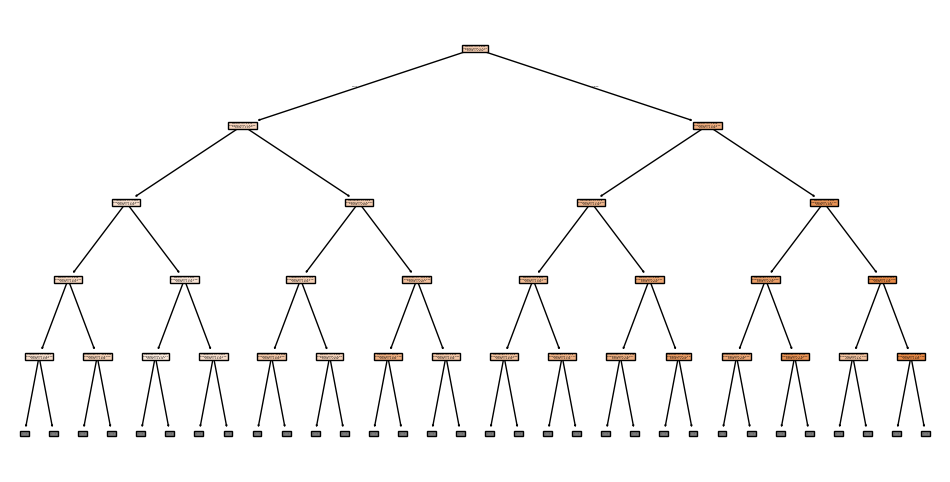

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plot_tree(
    model,
    max_depth=4,
    feature_names=["MedInc","HouseAge","AveRooms","Latitude","Longitude"],
    filled=True
    )
plt.show()

###  Hyperparameters Comparison
- Compare:
-criterion='squared_error' vs criterion='absolute_error'
- Try min_samples_leaf manually


- Answer
- (A) penalizes large errors more
- (b) sensitive to outliers
- (c) Usually gives better performance
- (2) criterion= 'absolute_error'
-     (A) Treats all errors equally
-     (B) More robust to outliers
-     (c) Slower to train

- Conclusion
- 1) Write a short conclusion including:
- Ans:- In this experiment, I learned how decision tree regression works and how different parameters affect model performance. I understood how controlling the tree structure helps improve accuracy and prevent errors on new data
- 2) What you learned about overfitting
    Ans:- Overfitting occurs when the model learns the training data too well, including noise, which leads to poor performance on test data. This usually happens when the decision tree is very deep and complex.
- 3) Importance of max_depth
-    Ans:-The max_depth parameter controls the depth of the tree. A smaller depth reduces overfitting by simplifying the model, while a larger depth increases complexity and may cause overfitting.
-4)  Why hyperparameter tuning is important
-    Ans:- Hyperparameter tuning is important because it helps find the best model settings. By adjusting parameters like max_depth and min_samples_leaf, we can improve accuracy and make the model perform better on unseen data.


